<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/05_GRU_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
from pathlib import Path

import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    GRU,
    Dense,
    Dropout,
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
LOOKBACK_DAYS = 30

In [5]:
shared_project_dir = Path(
    "/content/drive/MyDrive/Quant Research"
)

btc_data_dir = (
    shared_project_dir
    / "data"
    / "model_ready"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
)

results_dir = (
    shared_project_dir
    / "results"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
    / "GRU"
)

models_dir = (
    shared_project_dir
    / "models"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
    / "GRU"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [6]:
X_train = np.load(
    btc_data_dir / "X_train_scaled.npy"
)

X_val = np.load(
    btc_data_dir / "X_val_scaled.npy"
)

y_train = np.load(
    btc_data_dir / "y_train.npy"
)

y_val = np.load(
    btc_data_dir / "y_val.npy"
)

validation_metadata = pd.read_parquet(
    btc_data_dir
    / "validation_metadata.parquet"
)

with open(
    btc_data_dir / "dataset_configuration.json",
    "r",
    encoding="utf-8"
) as file:
    configuration = json.load(file)

In [7]:
print("Loaded dataset configuration:")
print("Candle interval:", configuration["candle_interval"])
print(
    "Variance definition:",
    configuration["variance_definition"]
)
print("Target:", configuration["target"])
print("Lookback:", configuration["lookback_days"])

assert (
    configuration["candle_interval"]
    == "1d"
)

assert (
    configuration["variance_definition"]
    == "squared_daily_log_return"
)

assert (
    int(configuration["lookback_days"])
    == LOOKBACK_DAYS
)

assert (
    configuration["target"]
    == "log_realized_variance"
)

print(
    "\nValidation period:",
    validation_metadata["target_date"].min(),
    "to",
    validation_metadata["target_date"].max()
)

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_train.shape[1:] == X_val.shape[1:]
assert len(validation_metadata) == len(y_val)

Loaded dataset configuration:
Candle interval: 1d
Variance definition: squared_daily_log_return
Target: log_realized_variance
Lookback: 30

Validation period: 2024-08-01 00:00:00+00:00 to 2025-07-31 00:00:00+00:00

Shapes:
X_train: (2481, 30, 7)
X_val: (365, 30, 7)
y_train: (2481,)
y_val: (365,)


In [8]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

assert X_train.shape[0] == y_train.shape[0]
assert X_val.shape[0] == y_val.shape[0]
assert X_train.shape[1:] == X_val.shape[1:]
assert len(validation_metadata) == len(y_val)

X_train: (2481, 30, 7)
X_val: (365, 30, 7)
y_train: (2481,)
y_val: (365,)


In [9]:
def build_gru_model(
    lookback_days,
    n_features
):
    model = Sequential(
        [
            Input(
                shape=(
                    lookback_days,
                    n_features
                )
            ),

            GRU(
                units=32,
                activation="tanh",
                recurrent_activation="sigmoid",
                return_sequences=False,
                dropout=0.0,
                recurrent_dropout=0.0,
            ),

            Dropout(rate=0.20),

            Dense(
                units=16,
                activation="relu"
            ),

            Dropout(rate=0.10),

            Dense(
                units=1,
                activation="linear"
            ),
        ],
        name="btc_gru_log_rv"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )

    return model

In [10]:
LOOKBACK_DAYS = X_train.shape[1]
N_FEATURES = X_train.shape[2]

gru_model = build_gru_model(
    lookback_days=LOOKBACK_DAYS,
    n_features=N_FEATURES
)

gru_model.summary()

Model: "btc_gru_log_rv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,481 (17.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
best_model_path = (
    models_dir
    / "best_gru_model.keras"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        min_delta=1e-4,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
]

In [12]:
history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=200,
    batch_size=32,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 74.1731 - mae: 8.2090
Epoch 1: val_loss improved from None to 61.64449, saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_30d/GRU/best_gru_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_30d/GRU/best_gru_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 76.3699 - mae: 8.3233 - val_loss: 61.6445 - val_mae: 7.4181 - learning_rate: 0.0010
Epoch 2/200
76/78 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 23.5052 - mae: 4.0562
Epoch 2: val_loss improved from 61.64449 to 6.67277, saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_30d/GRU/best_gru_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Quant Research/models/BTCUSDT/lookback_30d/GRU/best_gru_model.keras
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 15.1290 - mae: 3.0405 - val_loss: 6.6728 - val_mae: 1.9940 - learning_rate: 0.0010
Epoc

In [13]:
history_df = pd.DataFrame(
    history.history
)

history_df["epoch"] = (
    np.arange(len(history_df)) + 1
)

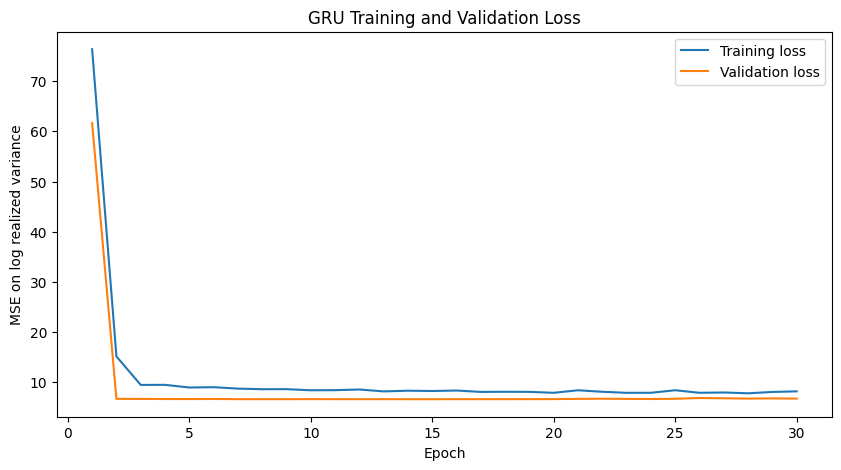

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["loss"],
    label="Training loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE on log realized variance")
plt.title("GRU Training and Validation Loss")
plt.legend()
plt.show()

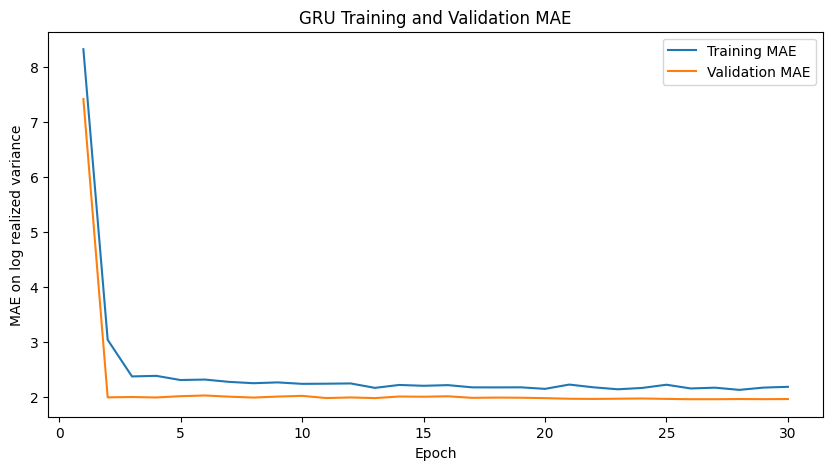

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_df["epoch"],
    history_df["mae"],
    label="Training MAE"
)

plt.plot(
    history_df["epoch"],
    history_df["val_mae"],
    label="Validation MAE"
)

plt.xlabel("Epoch")
plt.ylabel("MAE on log realized variance")
plt.title("GRU Training and Validation MAE")
plt.legend()
plt.show()

In [16]:
gru_pred_log_rv = (
    gru_model.predict(
        X_val,
        batch_size=32,
        verbose=0
    )
    .reshape(-1)
)

gru_pred_rv = np.exp(
    gru_pred_log_rv
)

actual_rv = validation_metadata[
    "actual_rv"
].to_numpy()

In [17]:
assert len(gru_pred_rv) == len(actual_rv)
assert np.isfinite(gru_pred_log_rv).all()
assert np.isfinite(gru_pred_rv).all()
assert (gru_pred_rv > 0).all()

print("Prediction checks passed.")

Prediction checks passed.


In [18]:
def mean_absolute_error(
    y_true,
    y_pred
):
    return np.mean(
        np.abs(
            np.asarray(y_true)
            - np.asarray(y_pred)
        )
    )


def root_mean_squared_error(
    y_true,
    y_pred
):
    return np.sqrt(
        np.mean(
            (
                np.asarray(y_true)
                - np.asarray(y_pred)
            ) ** 2
        )
    )


def qlike(
    y_true,
    y_pred,
    epsilon=1e-12
):
    y_true = np.maximum(
        np.asarray(y_true),
        epsilon
    )

    y_pred = np.maximum(
        np.asarray(y_pred),
        epsilon
    )

    ratio = y_true / y_pred

    return np.mean(
        ratio
        - np.log(ratio)
        - 1
    )


def evaluate_forecast(
    model_name,
    y_true,
    y_pred
):
    return {
        "model": model_name,
        "mae": mean_absolute_error(
            y_true,
            y_pred
        ),
        "rmse": root_mean_squared_error(
            y_true,
            y_pred
        ),
        "qlike": qlike(
            y_true,
            y_pred
        ),
    }

In [19]:
model_name = (
    f"GRU-{LOOKBACK_DAYS}d"
)

gru_result = evaluate_forecast(
    model_name=model_name,
    y_true=actual_rv,
    y_pred=gru_pred_rv
)

gru_result

{'model': 'GRU-30d',
 'mae': np.float64(0.000583823096825892),
 'rmse': np.float64(0.001435549384857426),
 'qlike': np.float64(5.5156494634184305)}

In [20]:
baseline_results_df = pd.read_csv(
    shared_project_dir
    / "results"
    / "BTCUSDT"
    / "baseline_validation_metrics.csv"
)

In [21]:
mlp_results_df = pd.read_csv(
    shared_project_dir
    / "results"
    / "BTCUSDT"
    / f"lookback_{LOOKBACK_DAYS}d"
    / "MLP"
    / "mlp_validation_metrics.csv"
)

In [22]:
comparison_df = pd.concat(
    [
        baseline_results_df,
        mlp_results_df,
        pd.DataFrame([gru_result]),
    ],
    ignore_index=True
)

comparison_df = (
    comparison_df
    .drop_duplicates(
        subset=["model"],
        keep="last"
    )
    .sort_values("qlike")
    .reset_index(drop=True)
)

comparison_df

,model,mae,rmse,qlike
0,30-Day Mean RV,0.000731,0.001355,1.878815
1,7-Day Mean RV,0.000768,0.001377,2.160473
2,MLP-30d,0.000592,0.001397,4.627228
3,GRU-30d,0.000584,0.001436,5.515649
4,Persistence,0.000892,0.001800,1878.685363


In [23]:
gru_predictions_df = (
    validation_metadata[
        [
            "symbol",
            "sequence_start_date",
            "sequence_end_date",
            "target_date",
            "actual_rv",
        ]
    ]
    .copy()
)

gru_predictions_df[
    "actual_log_rv"
] = y_val

gru_predictions_df[
    "gru_pred_log_rv"
] = gru_pred_log_rv

gru_predictions_df[
    "gru_pred_rv"
] = gru_pred_rv

In [24]:
history_df.to_csv(
    results_dir
    / "gru_training_history.csv",
    index=False
)

pd.DataFrame([gru_result]).to_csv(
    results_dir
    / "gru_validation_metrics.csv",
    index=False
)

comparison_df.to_csv(
    results_dir
    / "gru_model_comparison.csv",
    index=False
)

gru_predictions_df.to_parquet(
    results_dir
    / "gru_validation_predictions.parquet",
    index=False
)

gru_model.save(
    models_dir
    / "final_gru_model.keras"
)

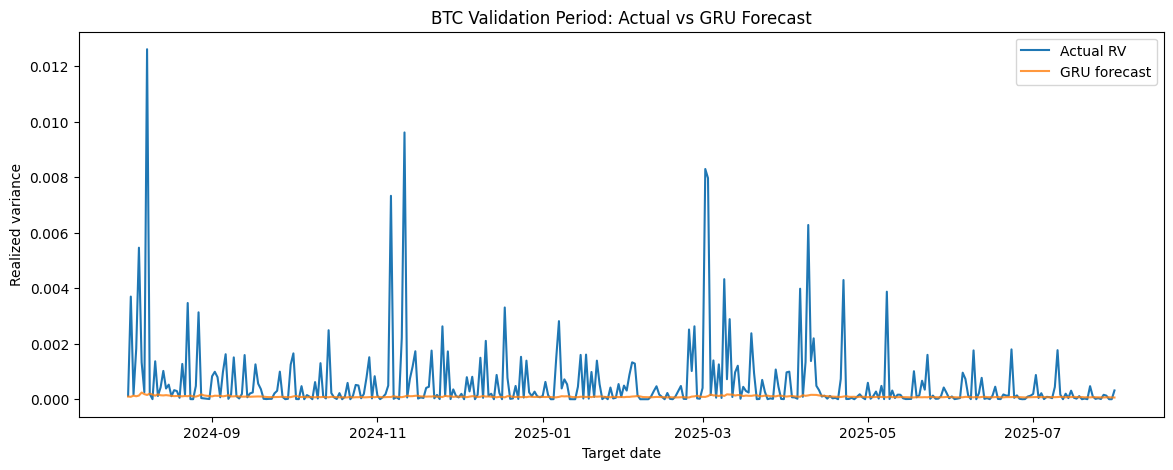

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(
    gru_predictions_df["target_date"],
    gru_predictions_df["actual_rv"],
    label="Actual RV"
)

plt.plot(
    gru_predictions_df["target_date"],
    gru_predictions_df["gru_pred_rv"],
    label="GRU forecast",
    alpha=0.8
)

plt.xlabel("Target date")
plt.ylabel("Realized variance")
plt.title(
    "BTC Validation Period: "
    "Actual vs GRU Forecast"
)

plt.legend()
plt.show()

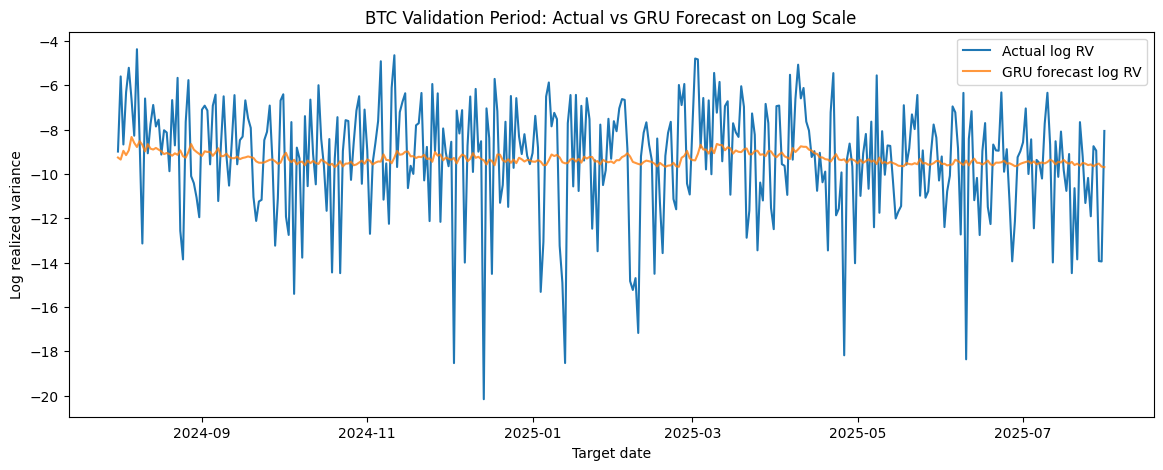

In [26]:
plt.figure(figsize=(14, 5))

plt.plot(
    gru_predictions_df["target_date"],
    gru_predictions_df["actual_log_rv"],
    label="Actual log RV"
)

plt.plot(
    gru_predictions_df["target_date"],
    gru_predictions_df["gru_pred_log_rv"],
    label="GRU forecast log RV",
    alpha=0.8
)

plt.xlabel("Target date")
plt.ylabel("Log realized variance")
plt.title(
    "BTC Validation Period: "
    "Actual vs GRU Forecast on Log Scale"
)

plt.legend()
plt.show()